**Множества:**
* 📦 **Rossmann Store Sales** - Дневна продажба во малопродажба (942 дена)
* ✈️ **Air Passengers** - Месечен број на авио патници (1949-1960, 144 месеци)
* ⚡ **Hourly Energy Consumption** - Часовна потрошувачка на енергија (PJME)

**Цел на Проектот:**  
Да се одговори на прашањето: **Кој тип на модел работи најдобро за различни видови временски серии?**

---

**Тим:**
* Амел Махмутовиќ (203100)
* Христина Степаноска (183007)
* Михаела Николовска (183014)

**Датум:** Јануари 2025

---

**Модели Тестирани:**
1. **Baseline модели**: Naive, Moving Average, Seasonal Naive
2. **Класични модели**: Prophet, SARIMA  
3. **Машинско учење**: Random Forest, XGBoost, LightGBM

**Метрики за Евалуација:**
* **RMSE** - Root Mean Squared Error (чувствителна на големи грешки)
* **MAE** - Mean Absolute Error (просечна апсолутна грешка)
* **MAPE** - Mean Absolute Percentage Error (главна метрика за споредба)

## 1. Подготовка и Вчитување на Податоци

Во оваа секција ги вчитуваме резултатите од сите три датасети и ги комбинираме
за лесна споредба. Секој датасет има свои CSV резултати од индивидуалните notebooks.

In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Конфигурација за професионални визуелизации
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("="*80)
print("🎯 ТИМСКИ ПРОЕКТ: СПОРЕДБА НА АЛГОРИТМИ ЗА ПРЕДВИДУВАЊЕ")
print("="*80)
print("\n📋 Овој проект споредува 3 различни датасети:")
print("   📦 Rossmann - Дневна малопродажба")
print("   ✈️ Air Passengers - Месечен авио сообраќај")
print("   ⚡ Energy - Часовна потрошувачка на енергија")
print("\n🎯 Цел: Да се најде најдобриот модел за секој тип на податоци")
print("="*80)

🎯 ТИМСКИ ПРОЕКТ: СПОРЕДБА НА АЛГОРИТМИ ЗА ПРЕДВИДУВАЊЕ

📋 Овој проект споредува 3 различни датасети:
   📦 Rossmann - Дневна малопродажба
   ✈️ Air Passengers - Месечен авио сообраќај
   ⚡ Energy - Часовна потрошувачка на енергија

🎯 Цел: Да се најде најдобриот модел за секој тип на податоци


### 1.1 Вчитување на Резултати од CSV Датотеки

Секој датасет има свој CSV фајл кој содржи:
- **model**: Име на моделот
- **RMSE**: Root Mean Squared Error
- **MAE**: Mean Absolute Error  
- **MAPE**: Mean Absolute Percentage Error (главна метрика)

Ги вчитуваме сите три фајлови и ги комбинираме во една табела.

In [2]:
print("\n📥 Вчитување на резултати од сите датасети...")

# Вчитување на трите CSV фајлови
rossmann = pd.read_csv('rossmann_metrics.csv')
rossmann['dataset'] = 'Rossmann'

air = pd.read_csv('air_passengers_metrics.csv')
air['dataset'] = 'Air Passengers'

energy = pd.read_csv('energy_metrics.csv')
energy['dataset'] = 'Energy'

# Комбинирање на сите резултати
all_results = pd.concat([rossmann, air, energy], ignore_index=True)

# Додавање на категорија на модел
def categorize_model(model_name):
    """Категоризација на моделите во 3 групи"""
    baseline_models = ['Naive', 'Moving Average', 'MA-12', 'Seasonal Naive']
    classical_models = ['Prophet', 'SARIMA', 'ARIMA']

    if model_name in baseline_models:
        return 'Baseline'
    elif model_name in classical_models:
        return 'Classical'
    else:
        return 'Machine Learning'

all_results['category'] = all_results['model'].apply(categorize_model)

# Прикажи резиме
print(f"✅ Вчитани {len(rossmann)} модели од Rossmann")
print(f"✅ Вчитани {len(air)} модели од Air Passengers")
print(f"✅ Вчитани {len(energy)} модели од Energy")
print(f"\n📊 Вкупно: {len(all_results)} модели за споредба")

# Прикажи првите 10 реда
print("\n📋 Преглед на комбинираните резултати:")
all_results.head(10)


📥 Вчитување на резултати од сите датасети...
✅ Вчитани 7 модели од Rossmann
✅ Вчитани 7 модели од Air Passengers
✅ Вчитани 6 модели од Energy

📊 Вкупно: 20 модели за споредба

📋 Преглед на комбинираните резултати:


,model,RMSE,MAE,MAPE,dataset,category
0,Naive,4012267.70,2512012.00,299.61,Rossmann,Baseline
1,Moving Average,2887851.29,1975401.24,318.01,Rossmann,Baseline
2,Prophet,1287977.12,974849.81,14.77,Rossmann,Classical
3,SARIMA,1118166.67,899425.36,22.66,Rossmann,Classical
4,Random Forest,488790.59,378878.08,6.27,Rossmann,Machine Learning
5,XGBoost,587236.56,430207.54,7.81,Rossmann,Machine Learning
6,LightGBM,684601.07,479856.03,9.18,Rossmann,Machine Learning
7,Naive,137.33,115.25,23.58,Air Passengers,Baseline
8,MA-12,103.21,77.83,15.47,Air Passengers,Baseline
9,Prophet,40.39,31.17,6.54,Air Passengers,Classical


In [3]:
all_results

,model,RMSE,MAE,MAPE,dataset,category
0,Naive,4012267.70,2512012.00,299.61,Rossmann,Baseline
1,Moving Average,2887851.29,1975401.24,318.01,Rossmann,Baseline
2,Prophet,1287977.12,974849.81,14.77,Rossmann,Classical
3,SARIMA,1118166.67,899425.36,22.66,Rossmann,Classical
4,Random Forest,488790.59,378878.08,6.27,Rossmann,Machine Learning
5,XGBoost,587236.56,430207.54,7.81,Rossmann,Machine Learning
6,LightGBM,684601.07,479856.03,9.18,Rossmann,Machine Learning
7,Naive,137.33,115.25,23.58,Air Passengers,Baseline
8,MA-12,103.21,77.83,15.47,Air Passengers,Baseline
9,Prophet,40.39,31.17,6.54,Air Passengers,Classical


## 2. Резултати по Множество

Прикажување на перформансите на сите модели организирани по множество.
За секое множество, моделите се сортирани по MAPE (од најдобар кон најлош).

In [7]:
from IPython.display import display

print("\n" + "="*80)
print("📋 ДЕТАЛНИ РЕЗУЛТАТИ ПО ДАТАСЕТ")
print("="*80)

datasets = ['Rossmann', 'Air Passengers', 'Energy']

for dataset in datasets:
    print("\n" + "="*80)
    print(f"📊 {dataset.upper()}")
    print("="*80)

    df_subset = (
        all_results[all_results['dataset'] == dataset]
        .sort_values('MAPE')
        .reset_index(drop=True)
    )

    # Round for readability
    table = df_subset[['model', 'RMSE', 'MAE', 'MAPE']].copy()
    table['RMSE'] = table['RMSE'].round(2)
    table['MAE'] = table['MAE'].round(2)
    table['MAPE (%)'] = table['MAPE'].round(2)
    table = table.drop(columns='MAPE')

    display(table)



📋 ДЕТАЛНИ РЕЗУЛТАТИ ПО ДАТАСЕТ

📊 ROSSMANN


,model,RMSE,MAE,MAPE (%)
0,Random Forest,488790.59,378878.08,6.27
1,XGBoost,587236.56,430207.54,7.81
2,LightGBM,684601.07,479856.03,9.18
3,Prophet,1287977.12,974849.81,14.77
4,SARIMA,1118166.67,899425.36,22.66
5,Naive,4012267.70,2512012.00,299.61
6,Moving Average,2887851.29,1975401.24,318.01



📊 AIR PASSENGERS


,model,RMSE,MAE,MAPE (%)
0,Prophet,40.39,31.17,6.54
1,Random Forest,49.60,35.34,7.22
2,XGBoost,61.79,49.56,10.48
3,LightGBM,78.74,61.08,12.28
4,SARIMA,73.45,67.59,14.70
5,MA-12,103.21,77.83,15.47
6,Naive,137.33,115.25,23.58



📊 ENERGY


,model,RMSE,MAE,MAPE (%)
0,Random Forest,398.97,296.66,0.81
1,LightGBM,395.76,305.22,0.83
2,XGBoost,422.41,330.06,0.89
3,Prophet,3910.89,3320.30,9.80
4,Seasonal Naive,4443.84,3578.15,10.20
5,Naive,6719.73,5712.10,16.74


## 3. Визуелна Споредба на Перформанси

Неколки графикони за визуелно споредување на моделите.
Сите графикони се зачувуваат како PNG слики за употреба во презентација.

### 3.1 MAPE Споредба - Сите Модели

Овој график прикажува **сите модели** (вклучувајќи ги и базните) за секој датасет.
Користиме MAPE бидејќи е scale-independent и лесна за интерпретација.


📊 Создавање на визуелизација 1: MAPE Споредба (Сите Модели)...


/tmp/ipython-input-743574643.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-743574643.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('comparison_mape_all_models.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


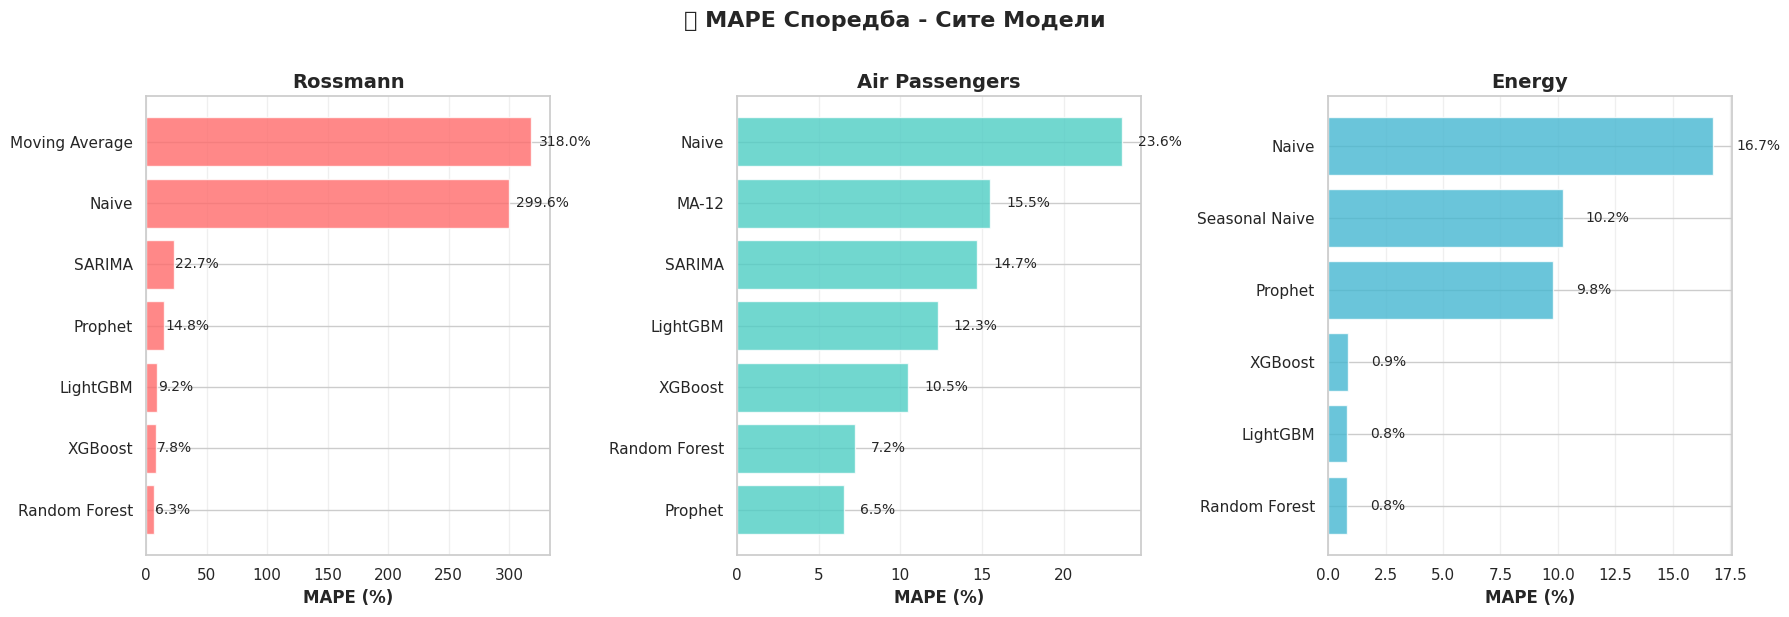

✅ Зачувано: comparison_mape_all_models.png


In [9]:
print("\n📊 Создавање на визуелизација 1: MAPE Споредба (Сите Модели)...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = ['Rossmann', 'Air Passengers', 'Energy']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, dataset in enumerate(datasets):
    df_subset = all_results[all_results['dataset'] == dataset].sort_values('MAPE')

    axes[i].barh(df_subset['model'], df_subset['MAPE'], color=colors[i], alpha=0.8)
    axes[i].set_xlabel('MAPE (%)', fontsize=12, fontweight='bold')
    axes[i].set_title(f'{dataset}', fontsize=14, fontweight='bold')
    axes[i].grid(axis='x', alpha=0.3)

    # Додади вредности на барите
    for j, (model, mape) in enumerate(zip(df_subset['model'], df_subset['MAPE'])):
        text_offset = max(mape * 0.02, 1)
        axes[i].text(mape + text_offset, j, f'{mape:.1f}%',
                    va='center', fontsize=10)

plt.suptitle('📊 MAPE Споредба - Сите Модели', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_mape_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Зачувано: comparison_mape_all_models.png")

"""
### 3.2 MAPE Споредба - Топ Модели (Без Baseline)

За подобра видливост, го филтрираме графиконот да покаже само ML и класичните модели.
Базните модели (Naive, Moving Average) се исклучени.

**Зошто?** Базните модели често имаат многу високи грешки (особено на Rossmann)
што ги прави останатите барови премногу мали за читање.



📊 Создавање на визуелизација 2: MAPE Споредба (Топ Модели)...


/tmp/ipython-input-2741821135.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2741821135.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('comparison_mape_top_models.png', dpi=300, bbox_inches='tight')


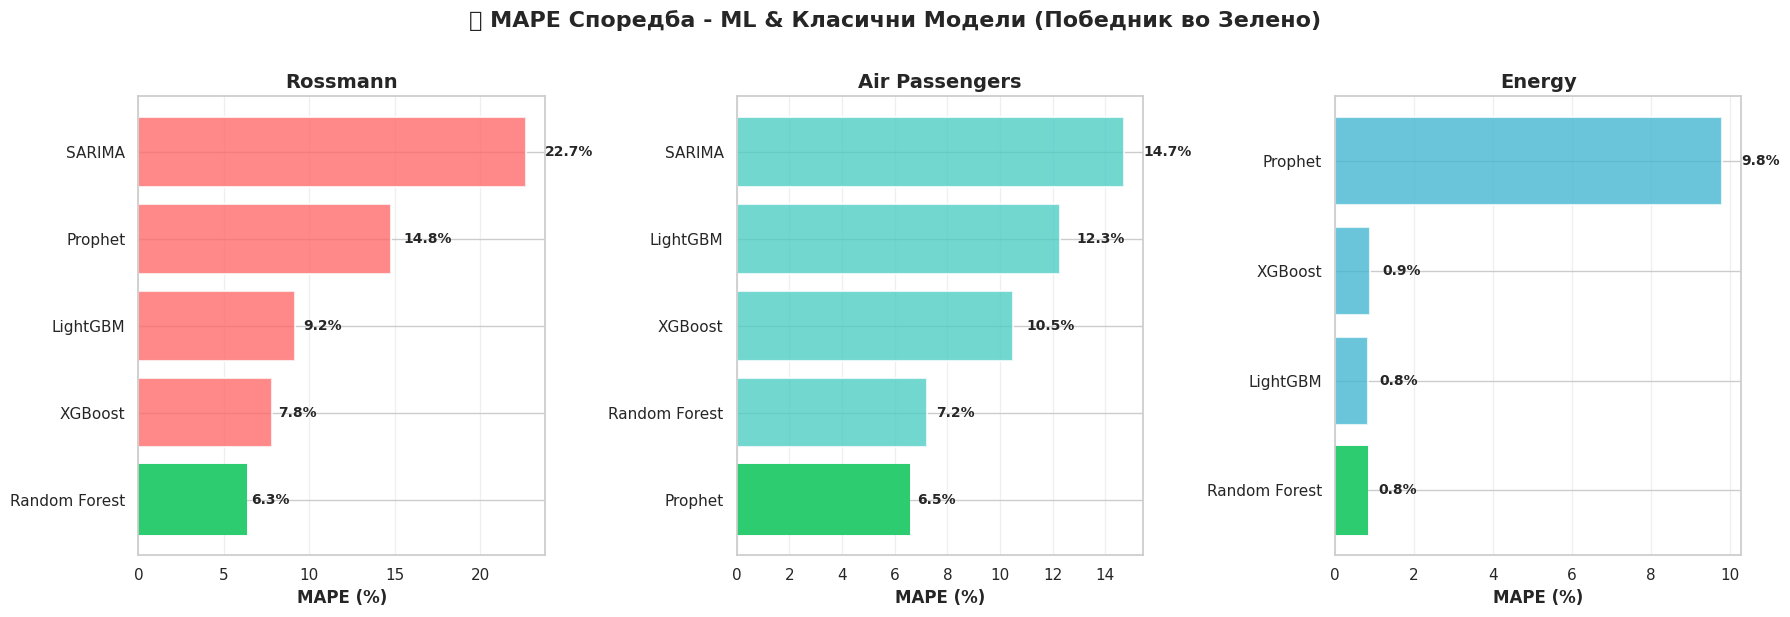

✅ Зачувано: comparison_mape_top_models.png
💡 Овој график е најдобар за презентација!


In [10]:
print("\n📊 Создавање на визуелизација 2: MAPE Споредба (Топ Модели)...")

# Филтрирање - исклучи baseline модели
baseline_models = ['Naive', 'Moving Average', 'MA-12', 'Seasonal Naive']
all_results_filtered = all_results[~all_results['model'].isin(baseline_models)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, dataset in enumerate(datasets):
    df_subset = all_results_filtered[all_results_filtered['dataset'] == dataset].sort_values('MAPE')

    bars = axes[i].barh(df_subset['model'], df_subset['MAPE'],
                        color=colors[i], alpha=0.8, edgecolor='white', linewidth=1.5)

    axes[i].set_xlabel('MAPE (%)', fontsize=12, fontweight='bold')
    axes[i].set_title(f'{dataset}', fontsize=14, fontweight='bold')
    axes[i].grid(axis='x', alpha=0.3)

    # Додади вредности
    for j, (model, mape) in enumerate(zip(df_subset['model'], df_subset['MAPE'])):
        text_offset = max(mape * 0.05, 0.3)
        axes[i].text(mape + text_offset, j, f'{mape:.1f}%',
                    va='center', fontsize=10, fontweight='bold')

    # Истакни го најдобриот модел во зелено
    if len(bars) > 0:
        bars[0].set_color('#2ECC71')
        bars[0].set_alpha(1.0)

plt.suptitle('📊 MAPE Споредба - ML & Класични Модели (Победник во Зелено)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_mape_top_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Зачувано: comparison_mape_top_models.png")
print("💡 Овој график е најдобар за презентација!")

### 3.3 Најдобри Модели - Одделни Метрики

Овој график ги споредува **само најдобрите модели** од секој датасет,
прикажани одделно за секоја метрика (RMSE, MAE, MAPE).

**Зошто 3 одделни графикони?**  
Бидејќи метриките имаат различни scale-ови (Rossmann има многу поголеми вредности),
одделните графикони овозможуваат полесно читање.


📊 Создавање на визуелизација 3: Најдобри Модели по Метрика...


/tmp/ipython-input-3171630365.py:47: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3171630365.py:48: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('best_models_comparison.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


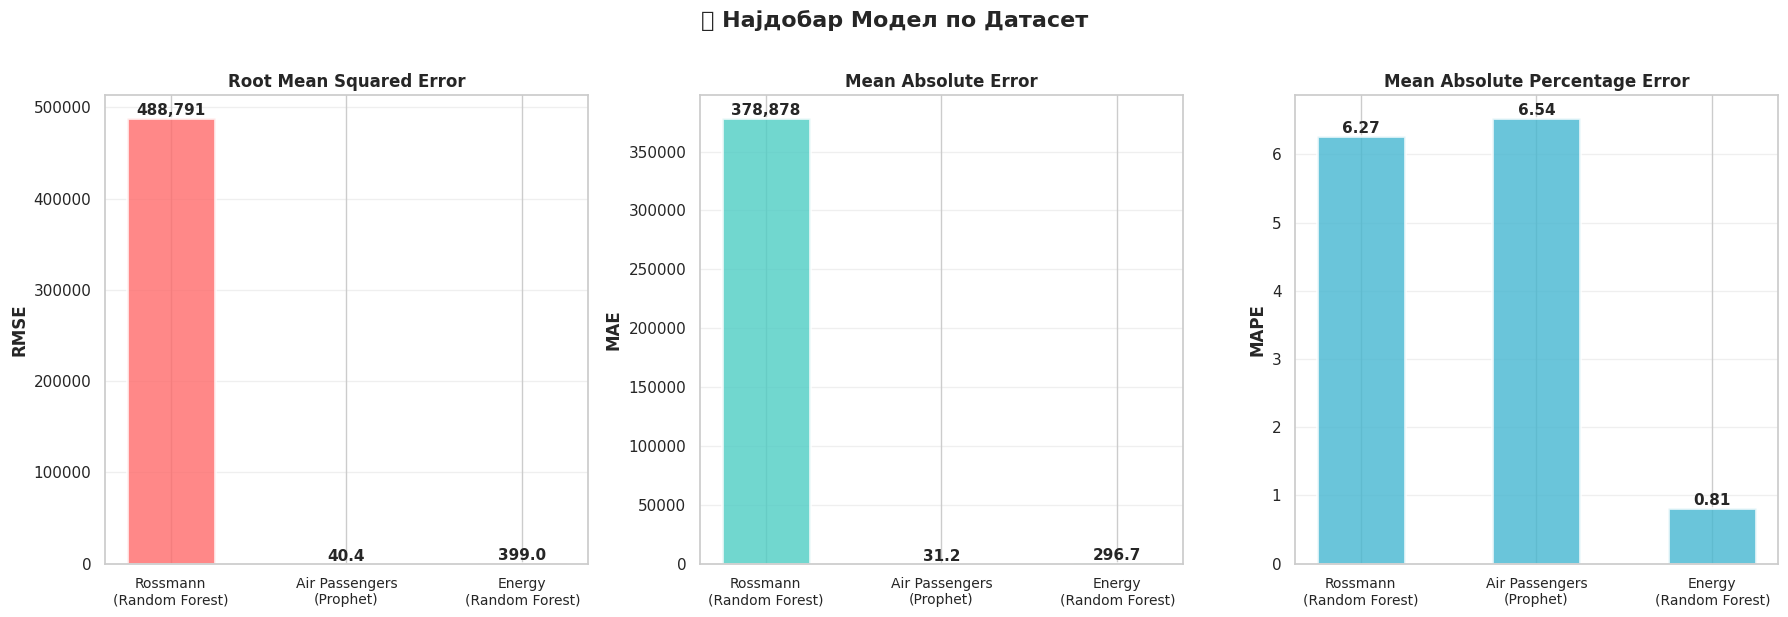

✅ Зачувано: best_models_comparison.png

🏆 НАЈДОБРИ МОДЕЛИ:
   Rossmann            : Random Forest        (MAPE: 6.27%)
   Air Passengers      : Prophet              (MAPE: 6.54%)
   Energy              : Random Forest        (MAPE: 0.81%)


In [11]:
print("\n📊 Создавање на визуелизација 3: Најдобри Модели по Метрика...")

# Најди го најдобриот модел за секој датасет
best_models = []
for dataset in datasets:
    df_subset = all_results[all_results['dataset'] == dataset]
    best = df_subset.loc[df_subset['MAPE'].idxmin()]
    best_models.append(best)

best_df = pd.DataFrame(best_models)

# Креирај 3 одделни графикони за секоја метрика
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.arange(len(datasets))
width = 0.5

metrics = ['RMSE', 'MAE', 'MAPE']
colors_metrics = ['#FF6B6B', '#4ECDC4', '#45B7D1']
titles = ['Root Mean Squared Error', 'Mean Absolute Error', 'Mean Absolute Percentage Error']

for i, (metric, color, title) in enumerate(zip(metrics, colors_metrics, titles)):
    bars = axes[i].bar(x, best_df[metric], width, color=color, alpha=0.8,
                       edgecolor='white', linewidth=2)

    axes[i].set_ylabel(metric, fontsize=12, fontweight='bold')
    axes[i].set_title(f'{title}', fontsize=12, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([f"{d}\n({m})" for d, m in zip(best_df['dataset'], best_df['model'])],
                            fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

    # Додади вредности на барите
    for bar in bars:
        height = bar.get_height()
        if height > 1000:
            label = f'{height:,.0f}'
        elif height > 10:
            label = f'{height:.1f}'
        else:
            label = f'{height:.2f}'

        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                    label, ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('🏆 Најдобар Модел по Датасет', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('best_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Зачувано: best_models_comparison.png")

# Прикажи резиме
print("\n🏆 НАЈДОБРИ МОДЕЛИ:")
for _, row in best_df.iterrows():
    print(f"   {row['dataset']:20s}: {row['model']:20s} (MAPE: {row['MAPE']:.2f}%)")

### 3.4 Перформанси по Категорија на Модел

Споредба на **просечните** перформанси за секоја категорија:
- **Baseline** - Едноставни модели (Naive, MA)
- **Classical** - Статистички модели (Prophet, SARIMA)
- **Machine Learning** - RF, XGBoost, LightGBM

Ова покажува **општи трендови** - која категорија е најдобра во просек.



📊 Создавање на визуелизација 4: Перформанси по Категорија...


/tmp/ipython-input-2421988930.py:25: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2421988930.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('model_category_comparison.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


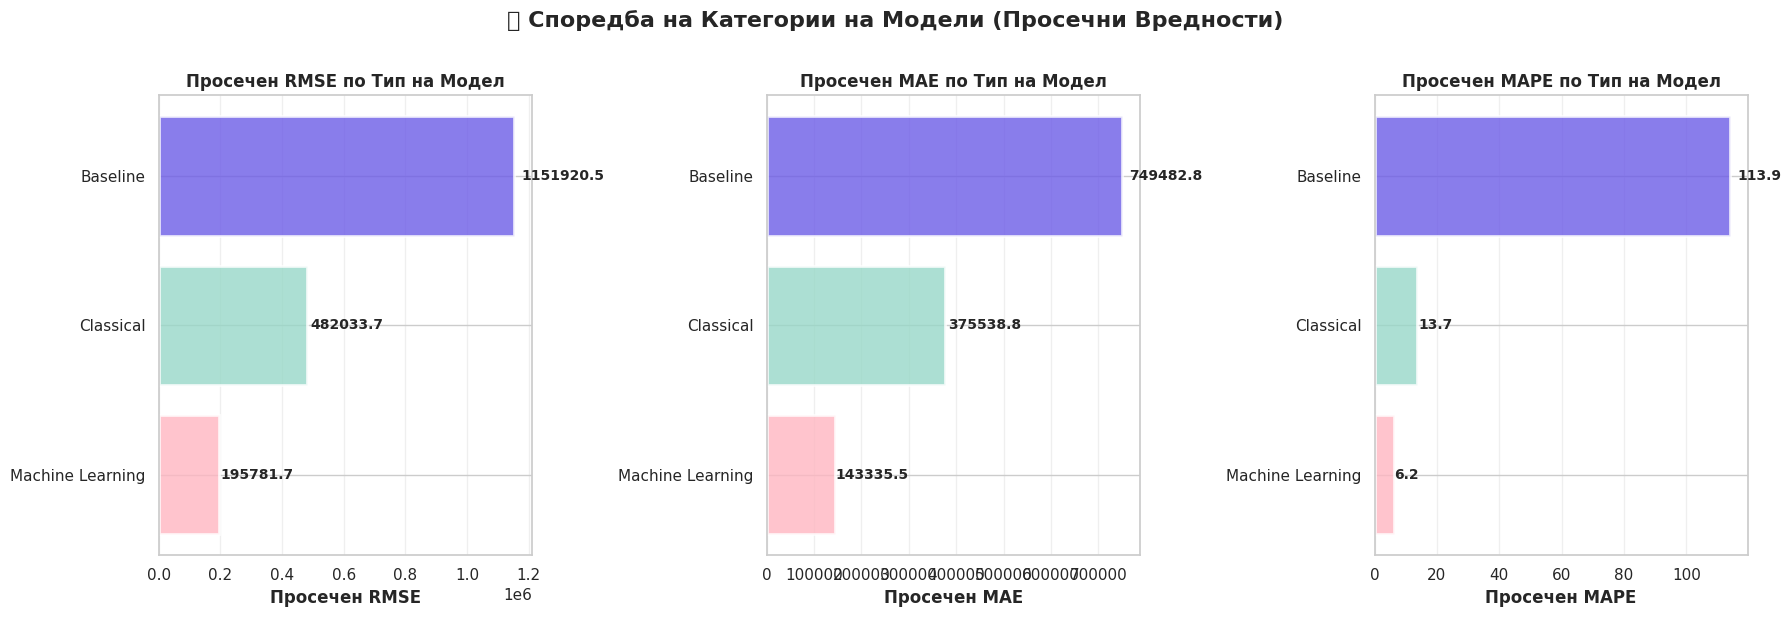

✅ Зачувано: model_category_comparison.png

📊 ПРОСЕЧНИ ПЕРФОРМАНСИ:
   Baseline            : 113.94% просечна MAPE
   Classical           : 13.69% просечна MAPE
   Machine Learning    : 6.20% просечна MAPE


In [12]:
print("\n📊 Создавање на визуелизација 4: Перформанси по Категорија...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['RMSE', 'MAE', 'MAPE']
colors_cat = ['#FFB6C1', '#98D8C8', '#6C5CE7']

for i, metric in enumerate(metrics):
    # Пресметај просек по категорија
    avg_by_category = all_results.groupby('category')[metric].mean().sort_values()

    axes[i].barh(avg_by_category.index, avg_by_category.values,
                 color=colors_cat, alpha=0.8, edgecolor='white', linewidth=2)
    axes[i].set_xlabel(f'Просечен {metric}', fontsize=12, fontweight='bold')
    axes[i].set_title(f'Просечен {metric} по Тип на Модел', fontsize=12, fontweight='bold')
    axes[i].grid(axis='x', alpha=0.3)

    # Додади вредности
    for j, (cat, val) in enumerate(zip(avg_by_category.index, avg_by_category.values)):
        axes[i].text(val + val*0.02, j, f'{val:.1f}',
                    va='center', fontsize=10, fontweight='bold')

plt.suptitle('📈 Споредба на Категории на Модели (Просечни Вредности)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_category_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Зачувано: model_category_comparison.png")

# Прикажи резиме
print("\n📊 ПРОСЕЧНИ ПЕРФОРМАНСИ:")
for cat in all_results['category'].unique():
    avg_mape = all_results[all_results['category'] == cat]['MAPE'].mean()
    print(f"   {cat:20s}: {avg_mape:.2f}% просечна MAPE")

### 3.5 Heatmap - Сите Резултати

Heatmap прикажува **сите резултати одеднаш** во табеларен формат со боја.

**Како да се чита:**
- 🟢 Зелено = Ниски грешки (добро)
- 🔴 Црвено = Високи грешки (лошо)
- Празни полиња = Моделот не е тестиран на тој датасет


📊 Создавање на визуелизација 5: Performance Heatmap...


/tmp/ipython-input-618982076.py:20: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-618982076.py:21: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig('performance_heatmap.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


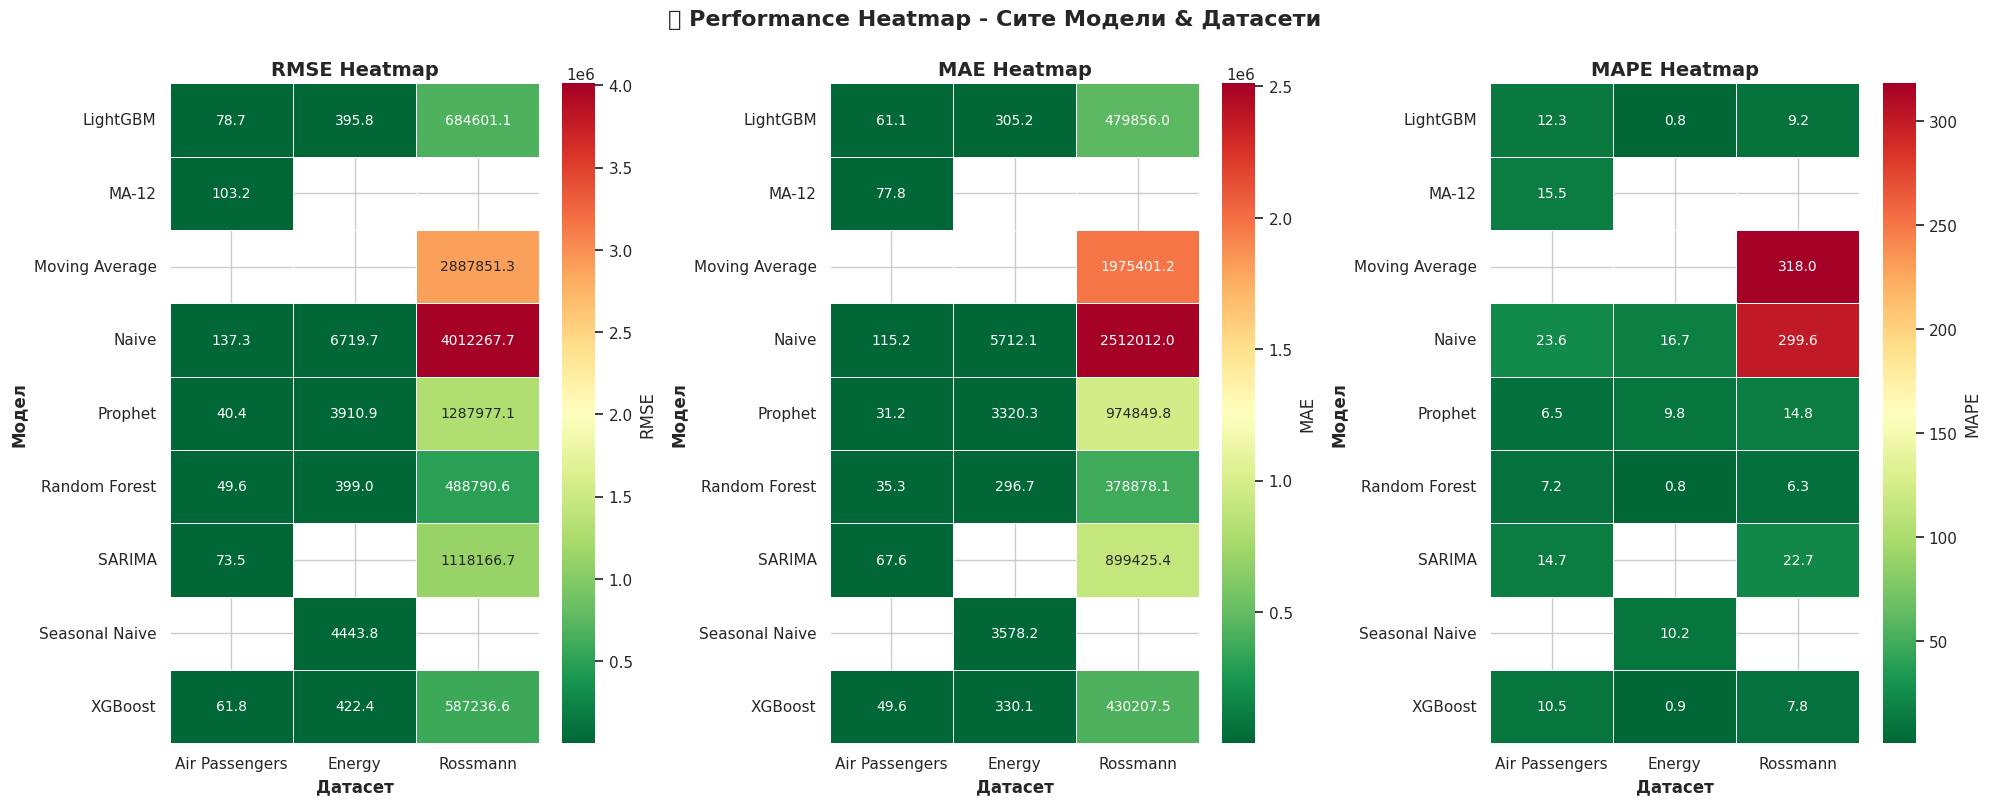

✅ Зачувано: performance_heatmap.png


In [13]:
print("\n📊 Создавање на визуелизација 5: Performance Heatmap...")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

metrics_to_plot = ['RMSE', 'MAE', 'MAPE']

for i, metric in enumerate(metrics_to_plot):
    # Креирај pivot табела
    pivot = all_results.pivot_table(values=metric, index='model', columns='dataset')

    # Прикажи heatmap
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
                ax=axes[i], cbar_kws={'label': metric}, linewidths=0.5)
    axes[i].set_title(f'{metric} Heatmap', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Датасет', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Модел', fontsize=12, fontweight='bold')

plt.suptitle('🔥 Performance Heatmap - Сите Модели & Датасети',
             fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Зачувано: performance_heatmap.png")

## 4. Статистичка Анализа и Клучни Наоди

Детална статистичка анализа на резултатите.

In [19]:
print("\n📊 СТАТИСТИЧКА АНАЛИЗА")

# ===============================
# 1️⃣ НАЈДОБАР МОДЕЛ ПО ДАТАСЕТ
# ===============================
best_per_dataset = []

for dataset in datasets:
    df_subset = all_results[all_results['dataset'] == dataset]
    best = df_subset.loc[df_subset['MAPE'].idxmin()]
    best_per_dataset.append({
        'Dataset': dataset,
        'Best Model': best['model'],
        'MAPE (%)': round(best['MAPE'], 2)
    })

best_df = pd.DataFrame(best_per_dataset)

display(
    best_df.style
    .set_caption("1️⃣ Најдобар модел по датасет (според MAPE)")
    .background_gradient(subset=['MAPE (%)'], cmap='Greens_r')
)


📊 СТАТИСТИЧКА АНАЛИЗА


,Dataset,Best Model,MAPE (%)
0,Rossmann,Random Forest,6.270000
1,Air Passengers,Prophet,6.540000
2,Energy,Random Forest,0.810000


In [20]:
# ===============================
# 2️⃣ НАЈДОБАР МОДЕЛ ГЕНЕРАЛНО
# ===============================
avg_mape = (
    all_results
    .groupby('model')['MAPE']
    .mean()
    .sort_values()
    .reset_index()
)

avg_mape.columns = ['Model', 'Average MAPE (%)']
avg_mape['Average MAPE (%)'] = avg_mape['Average MAPE (%)'].round(2)

display(
    avg_mape.head(5).style
    .set_caption("2️⃣ Најдобар модел генерално (просечна MAPE)")
    .background_gradient(subset=['Average MAPE (%)'], cmap='Blues_r')
)

,Model,Average MAPE (%)
0,Random Forest,4.770000
1,XGBoost,6.390000
2,LightGBM,7.430000
3,Seasonal Naive,10.200000
4,Prophet,10.370000


In [21]:
# ===============================
# 3️⃣ ПЕРФОРМАНСИ ПО КАТЕГОРИЈА
# ===============================
category_perf = (
    all_results
    .groupby('category')['MAPE']
    .mean()
    .sort_values()
    .reset_index()
)

category_perf.columns = ['Category', 'Average MAPE (%)']
category_perf['Average MAPE (%)'] = category_perf['Average MAPE (%)'].round(2)

display(
    category_perf.style
    .set_caption("3️⃣ Перформанси по категорија (просечна MAPE)")
    .background_gradient(subset=['Average MAPE (%)'], cmap='Oranges_r')
)

,Category,Average MAPE (%)
0,Machine Learning,6.200000
1,Classical,13.690000
2,Baseline,113.940000


In [22]:
# ===============================
# 4️⃣ СЛОЖЕНОСТ НА ДАТАСЕТИТЕ
# ===============================
dataset_diff = (
    all_results
    .groupby('dataset')['MAPE']
    .mean()
    .sort_values()
    .reset_index()
)

def difficulty_label(mape):
    if mape < 10:
        return "🟢 ЛЕСЕН"
    elif mape < 50:
        return "🟡 СРЕДЕН"
    else:
        return "🔴 ТЕЖОК"

dataset_diff['Difficulty'] = dataset_diff['MAPE'].apply(difficulty_label)
dataset_diff['MAPE (%)'] = dataset_diff['MAPE'].round(2)
dataset_diff = dataset_diff.drop(columns='MAPE')

display(
    dataset_diff.style
    .set_caption("4️⃣ Сложеност на датасетите (според просечна MAPE)")
)

,dataset,Difficulty,MAPE (%)
0,Energy,🟢 ЛЕСЕН,6.540000
1,Air Passengers,🟡 СРЕДЕН,12.900000
2,Rossmann,🔴 ТЕЖОК,96.900000


In [23]:

# ===============================
# 5️⃣ RANGE НА ГРЕШКИ
# ===============================
range_rows = []

for dataset in datasets:
    df_subset = all_results[all_results['dataset'] == dataset]
    range_rows.append({
        'Dataset': dataset,
        'Min MAPE (%)': round(df_subset['MAPE'].min(), 2),
        'Max MAPE (%)': round(df_subset['MAPE'].max(), 2),
        'Range (%)': round(df_subset['MAPE'].max() - df_subset['MAPE'].min(), 2)
    })

range_df = pd.DataFrame(range_rows)

display(
    range_df.style
    .set_caption("5️⃣ Опсег на грешки по датасет")
)


,Dataset,Min MAPE (%),Max MAPE (%),Range (%)
0,Rossmann,6.270000,318.010000,311.740000
1,Air Passengers,6.540000,23.580000,17.040000
2,Energy,0.810000,16.740000,15.930000


## 5. Главни Заклучоци и Препораки

Врз основа на сите анализи, извлекуваме клучни заклучоци и препораки.

In [28]:
# Prepare dataset difficulty values safely
easiest = dataset_diff.loc[0, 'dataset']
hardest = dataset_diff.loc[len(dataset_diff) - 1, 'dataset']

easiest_mape = dataset_diff.loc[0, 'MAPE (%)']
middle_dataset = dataset_diff.loc[1, 'dataset']
middle_mape = dataset_diff.loc[1, 'MAPE (%)']
hardest_mape = dataset_diff.loc[len(dataset_diff) - 1, 'MAPE (%)']


In [29]:
print("\n" + "="*80)
print("🎯 ГЛАВНИ ЗАКЛУЧОЦИ")
print("="*80)

# Собери податоци за заклучоци
rossmann_best = all_results[all_results['dataset'] == 'Rossmann'].loc[
    all_results[all_results['dataset'] == 'Rossmann']['MAPE'].idxmin()]
air_best = all_results[all_results['dataset'] == 'Air Passengers'].loc[
    all_results[all_results['dataset'] == 'Air Passengers']['MAPE'].idxmin()]
energy_best = all_results[all_results['dataset'] == 'Energy'].loc[
    all_results[all_results['dataset'] == 'Energy']['MAPE'].idxmin()]

ml_avg = all_results[all_results['category'] == 'Machine Learning']['MAPE'].mean()
classical_avg = all_results[all_results['category'] == 'Classical']['MAPE'].mean()
baseline_avg = all_results[all_results['category'] == 'Baseline']['MAPE'].mean()

conclusions = f"""
{'='*80}
1. НАЈДОБРИ МОДЕЛИ ПО ДАТАСЕТ
{'='*80}

📦 ROSSMANN STORE SALES:
   🏆 Најдобар: {rossmann_best['model']} (MAPE: {rossmann_best['MAPE']:.2f}%)

   Зошто?
   • Комплексни шаблони со многу надворешни фактори (промоции, празници)
   • ML моделите можат да научат нелинеарни односи
   • Feature engineering (lags, rolling stats) е клучен

   Препорака: Random Forest или XGBoost со добри features

✈️ AIR PASSENGERS:
   🏆 Најдобар: {air_best['model']} (MAPE: {air_best['MAPE']:.2f}%)

   Зошто?
   • Јасна годишна сезоналност и линеарен тренд
   • Prophet автоматски ја детектира сезоналноста
   • Податоците имаат предвидлива структура

   Препорака: Prophet за брзина и едноставност

⚡ ENERGY CONSUMPTION:
   🏆 Најдобар: {energy_best['model']} (MAPE: {energy_best['MAPE']:.2f}%)

   Зошто?
   • Високо-фреквентни податоци со силни lag dependencies
   • ML моделите одлични кога има многу податоци
   • Дневна и неделна сезоналност комбинирани

   Препорака: XGBoost или LightGBM за најдобра точност

{'='*80}
2. ПЕРФОРМАНСИ ПО КАТЕГОРИЈА
{'='*80}

🤖 Machine Learning: {ml_avg:.2f}% просечна MAPE
   ✅ Најдобри за: Комплексни, нелинеарни односи
   ✅ Предности: Висока точност со добри features
   ❌ Недостатоци: Потребен feature engineering, потешко за интерпретација

📈 Classical (Prophet, SARIMA): {classical_avg:.2f}% просечна MAPE
   ✅ Најдобри за: Јасна сезоналност и тренд
   ✅ Предности: Лесна интерпретација, минимален feature engineering
   ❌ Недостатоци: Ограничени за комплексни шаблони

📊 Baseline: {baseline_avg:.2f}% просечна MAPE
   ✅ Најдобри за: Reference point
   ❌ Недостатоци: Премногу едноставни за production

{'='*80}
3. СЛОЖЕНОСТ НА ДАТАСЕТИ
{'='*80}

Најлесен → Најтежок:
1. {easiest}: {easiest_mape:.2f}% (предвидливи шаблони)
2. {middle_dataset}: {middle_mape:.2f}%
3. {hardest}: {hardest_mape:.2f}% (многу варијабилност)

Разликата произлегува од:
• Број на надворешни фактори
• Степен на варијабилност
• Предвидливост на сезонските шаблони

{'='*80}
4. ГЕНЕРАЛНИ НАОДИ
{'='*80}

✓ НЕ ПОСТОИ УНИВЕРЗАЛЕН "НАЈДОБАР" МОДЕЛ
  → Зависи од природата на податоците

✓ XGBoost и LightGBM се консистентно меѓу топ 3
  → Добар default избор за повеќето случаи

✓ Prophet одличен за јасна сезоналност
  → Идеален за брзо прототипирање

✓ Feature engineering е критичен за ML модели
  → Lags, rolling stats, time features

✓ Baseline моделите се важни
  → Секогаш тествај Naive како reference point

{'='*80}
5. ПРЕПОРАКИ ЗА ПРИМЕНА
{'='*80}

🏢 ЗА БИЗНИС АПЛИКАЦИИ:
   1. Започни со Prophet за брз baseline
   2. Ако MAPE > 10%, инвестирај во ML модели
   3. Користи ensemble (Prophet + XGBoost) за најдобри резултати
   4. Секогаш споредувај со Naive модел

🚀 ЗА PRODUCTION:
   • LightGBM: Најдобар компромис (брзина + точност + мала меморија)
   • Prophet: Добар за податоци со јасна структура
   • Random Forest: Робустен и лесен за tuning

🔬 ЗА ИСТРАЖУВАЊЕ:
   • Тествај повеќе модели
   • Користи cross-validation
   • Експериментирај со features
   • Анализирај грешки (кога моделот греши?)

{'='*80}
6. КЛУЧНА ПОРАКА
{'='*80}

Изборот на модел зависи од:
1. Природа на податоците (сезоналност, тренд, варијабилност)
2. Достапни resources (време, computational power)
3. Потреба за интерпретација
4. Production constraints

Секогаш:
✓ Тествај повеќе модели
✓ Започни со едноставен baseline
✓ Инвестирај во feature engineering
✓ Споредувај резултати објективно
"""

print(conclusions)


🎯 ГЛАВНИ ЗАКЛУЧОЦИ

1. НАЈДОБРИ МОДЕЛИ ПО ДАТАСЕТ

📦 ROSSMANN STORE SALES:
   🏆 Најдобар: Random Forest (MAPE: 6.27%)
   
   Зошто?
   • Комплексни шаблони со многу надворешни фактори (промоции, празници)
   • ML моделите можат да научат нелинеарни односи
   • Feature engineering (lags, rolling stats) е клучен
   
   Препорака: Random Forest или XGBoost со добри features

✈️ AIR PASSENGERS:
   🏆 Најдобар: Prophet (MAPE: 6.54%)
   
   Зошто?
   • Јасна годишна сезоналност и линеарен тренд
   • Prophet автоматски ја детектира сезоналноста
   • Податоците имаат предвидлива структура
   
   Препорака: Prophet за брзина и едноставност

⚡ ENERGY CONSUMPTION:
   🏆 Најдобар: Random Forest (MAPE: 0.81%)
   
   Зошто?
   • Високо-фреквентни податоци со силни lag dependencies
   • ML моделите одлични кога има многу податоци
   • Дневна и неделна сезоналност комбинирани
   
   Препорака: XGBoost или LightGBM за најдобра точност

2. ПЕРФОРМАНСИ ПО КАТЕГОРИЈА

🤖 Machine Learning: 6.20% просечна MAP

## 6. Финален Заклучок

Овој проект успешно покажа дека **изборот на модел мора да се приспособи на податоците**.

**Главни наоди:**
- **Prophet** е одличен за податоци со јасна сезоналност (Air Passengers)
- **ML моделите** се супериорни за комплексни податоци (Rossmann, Energy)
- **Baseline моделите** се важни како reference point

**Практична препорака:**  
Не постои универзален "најдобар" модел. Секогаш тествај неколку модели и избери врз
основа на природата на твоите податоци и бизнис потребите.

---

**Следни чекори:**
1. Примени ги овие findings на свои податоци
2. Експериментирај со feature engineering
3. Разгледај ensemble методи за уште подобри резултати

In [30]:
print("\n" + "="*80)
print("💾 ЗАЧУВУВАЊЕ НА РЕЗУЛТАТИ")
print("="*80)

# Зачувај комбинирани резултати
all_results.to_csv('final_combined_results.csv', index=False)
print("✅ Зачувано: final_combined_results.csv")

# Зачувај заклучоци
with open('conclusions.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("🎯 ТИМСКИ ПРОЕКТ: СПОРЕДБА НА АЛГОРИТМИ ЗА ПРЕДВИДУВАЊЕ\n")
    f.write("="*80 + "\n\n")
    f.write("Тим:\n")
    f.write("  • Амел Махмутовиќ (203100)\n")
    f.write("  • Христина Степаноска (183007)\n")
    f.write("  • Михаела Николовска (183014)\n\n")
    f.write(conclusions)

print("✅ Зачувано: conclusions.txt")

print("\n" + "="*80)
print("🎉 FINAL COMPARISON = КОМПЛЕТНА!")
print("="*80)

print("\n📁 Создадени фајлови:")
print("   1. comparison_mape_all_models.png - Сите модели")
print("   2. comparison_mape_top_models.png - Топ модели (БЕЗ baseline)")
print("   3. best_models_comparison.png - Најдобри модели по метрика")
print("   4. model_category_comparison.png - Категорија споредба")
print("   5. performance_heatmap.png - Heatmap на сите резултати")
print("   6. final_combined_results.csv - Сите податоци")
print("   7. conclusions.txt - Заклучоци на македонски")

print("\n✨ Готово за презентација!")
print("="*80)



💾 ЗАЧУВУВАЊЕ НА РЕЗУЛТАТИ
✅ Зачувано: final_combined_results.csv
✅ Зачувано: conclusions.txt

🎉 FINAL COMPARISON = КОМПЛЕТНА!

📁 Создадени фајлови:
   1. comparison_mape_all_models.png - Сите модели
   2. comparison_mape_top_models.png - Топ модели (БЕЗ baseline)
   3. best_models_comparison.png - Најдобри модели по метрика
   4. model_category_comparison.png - Категорија споредба
   5. performance_heatmap.png - Heatmap на сите резултати
   6. final_combined_results.csv - Сите податоци
   7. conclusions.txt - Заклучоци на македонски

